![alternative text](../logo.png)

# Agroclimatic Indicators – growing season length example

This notebook shows how to retrieve **agroclimatic climate-projection data** using the `sis-agroclimatic-indicators` dataset, using growing season length as an example.

In this example, you will:

1. Build and send a data request using a **bounding box** or a **polygon**
2. Decode the CoverageJSON data into an **xarray Dataset**
3. Visualise the data using the EarthKit plots package (Optional)

---

### What are agroclimatic indicators?

Agroclimatic indicators are derived from climate projections relevant to the agricultural sector. The dataset includes variables such as growing season length, heavy precipitation days, and the number of tropical nights across different climate scenarios and time periods. This type of data is used for long-term crop planning and climate-risk assessment.

More information about **available variables** and **request fields** can be found in: 
- README and constraints/sis-ecde-climate-indicators.json
- https://cds.climate.copernicus.eu/datasets/sis-agroclimatic-indicators?tab=overview



## Imports and shared settings

In [ ]:
# Uncomment and run this cell if you need to install the dependencies
#!pip install -r requirements.txt

In [1]:
#Data requests and decode
import requests
from covjsonkit.api import Covjsonkit

#Data visualisation
import earthkit.plots as ekp
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="earthkit")

# API endpoint template
base_url = 'https://polytope-dss.ecmwf.int/api/v1/dataset/{dataset}/extract/'

headers = {
    'accept': 'application/json',
    'Content-Type': 'application/json',
}

---

## Example 1 – Bounding-box query

A **bounding box** selects all grid points inside a rectangular region defined by
two corner coordinates: `[lat_min, lon_min]` and `[lat_max, lon_max]`.

In this request, we retrieve **growing season length** for the time period from January 2011 to December 2040.

Model NorESM1-M and scenario RCP4.5 are the defaults. If you wish to use another model and/or scenario, uncomment these fields and change the values.

The bounding box covers an area in **western Europe** (roughly 35°N–60°N, 10°W–10°E).

The API returns data in **CoverageJSON** format. 

### 1.1 Send the request

In [2]:
bbox_request = {
    'request': {
        'variable': ['growing_season_length'],
        'temporal_aggregation': 'annual',
        'period': ['201101_204012'],
        # Optional – uncomment to pin a specific model or scenario:
        # 'origin': 'noresm1_m_model',
        # 'experiment': 'rcp4_5',
    },
    'feature': {
        'type': 'boundingbox',
        # Coordinates are [lat_min, lon_min] and [lat_max, lon_max]
        'coordinates': [[35, -10], [60, 10]],
    },
}

url = base_url.format(dataset='sis-agroclimatic-indicators')
response_bbox = requests.post(url, headers=headers, json=bbox_request)

#Print the response status code
print('Status:', response_bbox.status_code)

Status: 200


### 1.2 Decode the response

The module `covjsonkit` converts the downloaded CoverageJSON dataset into an [xarray Dataset](https://docs.xarray.dev/en/stable/), which gives us a labelled overview of the dataset and makes future post-processing straightforward.


In [3]:
decoder_bbox = Covjsonkit().decode(response_bbox.json())
ds_bbox = decoder_bbox.to_xarray()
ds_bbox

<xarray.Dataset> Size: 546kB
Dimensions:    (datetimes: 30, number: 1, steps: 1, points: 2000)
Coordinates:
  * datetimes  (datetimes) <U19 2kB '2011-07-01 00:00:00' ... '2040-07-01 00:...
  * number     (number) int64 8B 0
  * steps      (steps) int64 8B 0
  * points     (points) int64 16kB 0 1 2 3 4 5 ... 1994 1995 1996 1997 1998 1999
    latitude   (points) float64 16kB 35.25 35.25 35.25 ... 59.75 59.75 59.75
    longitude  (points) float64 16kB -9.75 -9.25 -8.75 -8.25 ... 8.75 9.25 9.75
    levelist   (points) float64 16kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Data variables:
    GSL        (datetimes, number, steps, points) float64 480kB -1.0 ... 171.0
Attributes:
    number:   0
    step:     0
    date:     2011-07-01 00:00:00

### 1.3 Visualise the data

In this example, we are going to plot how much growing season length changes by 2040 compared to 2011.
First, we compute this difference and save it as a new variable in the xarray dataset.

In [4]:
ds_bbox['GSL_diff'] = ds_bbox['GSL'].isel(datetimes=-1) - ds_bbox['GSL'].isel(datetimes=0) #compute difference
ds_bbox['GSL_diff'].attrs = {'type':'Parameter','units':'days','long_name':'GSL_diff'} #add attributes
ds_bbox['GSL_diff']

<xarray.DataArray 'GSL_diff' (number: 1, steps: 1, points: 2000)> Size: 16kB
array([[[  0.,   0.,   0., ..., -41.,  -6.,  -3.]]], shape=(1, 1, 2000))
Coordinates:
  * number     (number) int64 8B 0
  * steps      (steps) int64 8B 0
  * points     (points) int64 16kB 0 1 2 3 4 5 ... 1994 1995 1996 1997 1998 1999
    latitude   (points) float64 16kB 35.25 35.25 35.25 ... 59.75 59.75 59.75
    longitude  (points) float64 16kB -9.75 -9.25 -8.75 -8.25 ... 8.75 9.25 9.75
    levelist   (points) float64 16kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Attributes:
    type:       Parameter
    units:      days
    long_name:  GSL_diff

We use **Earthkit Plots** package to visualise the data. 
Please, find more information and documentation of the package here:
https://earthkit-plots.readthedocs.io


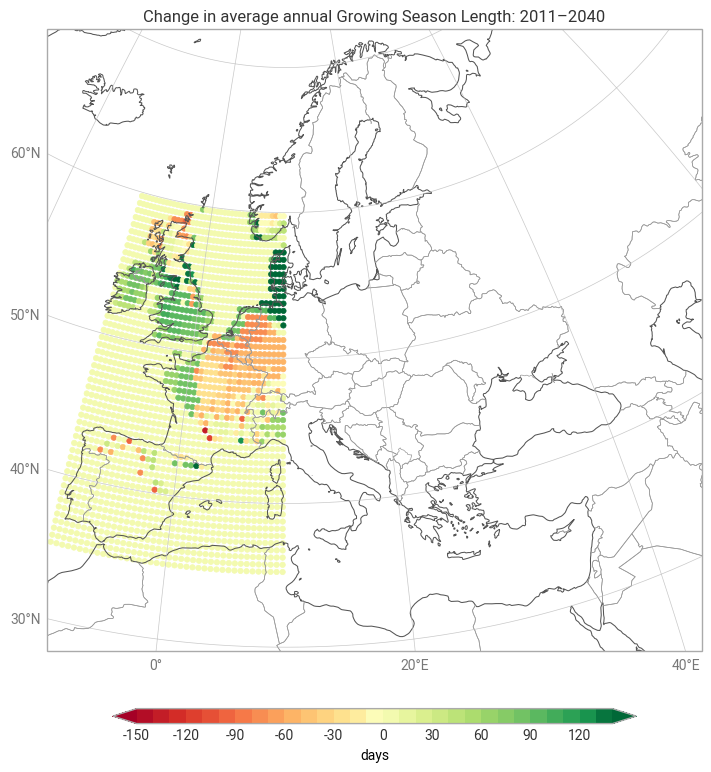

In [5]:
chart = ekp.Map(domain="Europe")
chart.point_cloud(ds_bbox['GSL_diff'],
    x=ds_bbox['longitude'],
    y=ds_bbox['latitude'],
    s=15,
    style=ekp.Style(levels=range(-150, 150, 10), colors='RdYlGn', extend="both"))

chart.coastlines()
chart.borders()
chart.gridlines()

chart.title("Change in average annual Growing Season Length: 2011–2040")

chart.legend(label='days')

chart.show()

We can see that based on NorESM1-M model and RCP4.5 projection, in 2040 there will be more growing season days in green dots areas and less growing season days in reddish areas, compared to 2011.

---

## Example 2 – Polygon query

A **polygon** selects grid points inside an arbitrary shape. This is useful when
your area of interest follows administrative boundaries, a river catchment, or
any non-rectangular outline.

Rules for polygon coordinates:

- Each point is `[lat, lon]`
- The polygon must be **closed**: the first and last point must be identical
- At least 4 points are needed (3 unique corners + the closing repeat)

The polygon below roughly traces the area representing the **Corn Belt** in the USA - one of the world's most fertile lands. Notice that **only the `feature` block changes** – the `request` dict is the same as in a bounding box example.


### 2.1 Send the request

In [6]:
polygon_request = {
    'request': {
        'variable': ['growing_season_length'],
        'temporal_aggregation': 'annual',
        'period': ['201101_204012'],
        # 'origin': 'noresm1_m_model',
        # 'experiment': 'rcp4_5',
    },
    'feature': {
        'type': 'polygon',
        # Closed polygon of [lat, lon] pairs – first point must equal last point
        'coordinates': [
            [40.0,-97.8],  # south-central Nebraska
            [42.8,-97.5],  # eastern Nebraska / South Dakota border
            [44.8,-95.0],  # southern Minnesota
            [44.9,-91.0],  # Wisconsin border area
            [41.8,-86.5],  # Indiana / western Ohio
            [39.8,-84.8],  # Ohio River valley
            [37.0,-89.0],  # southern Illinois
            [38.0,-94.5],  # Missouri / Kansas
            [40.0,-97.8]   # close polygon
        ],
    },
}

url_poly = base_url.format(dataset='sis-agroclimatic-indicators')
response_poly = requests.post(url_poly, headers=headers, json=polygon_request)

# Print the response status code
print(response_poly.status_code)


200


### 2.2 Decode the response

As in the previous example, we use `covjsonkit` module to convert the downloaded CoverageJSON dataset into an xarray.

In [7]:
decoder_poly = Covjsonkit().decode(response_poly.json())
ds_poly = decoder_poly.to_xarray()
ds_poly

<xarray.Dataset> Size: 78kB
Dimensions:    (datetimes: 30, number: 1, steps: 1, points: 280)
Coordinates:
  * datetimes  (datetimes) <U19 2kB '2011-07-01 00:00:00' ... '2040-07-01 00:...
  * number     (number) int64 8B 0
  * steps      (steps) int64 8B 0
  * points     (points) int64 2kB 0 1 2 3 4 5 6 ... 273 274 275 276 277 278 279
    latitude   (points) float64 2kB 37.25 37.25 37.25 ... 44.75 44.75 44.75
    longitude  (points) float64 2kB -90.25 -89.75 -89.25 ... -91.75 -91.25
    levelist   (points) float64 2kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Data variables:
    GSL        (datetimes, number, steps, points) float64 67kB 283.0 ... 225.0
Attributes:
    number:   0
    step:     0
    date:     2011-07-01 00:00:00

### 2.3 Visualise the data
In this example we are goint to plot Growth Season Length in Corn Belt in 2011 and in 2040 based on the retrieved projection.

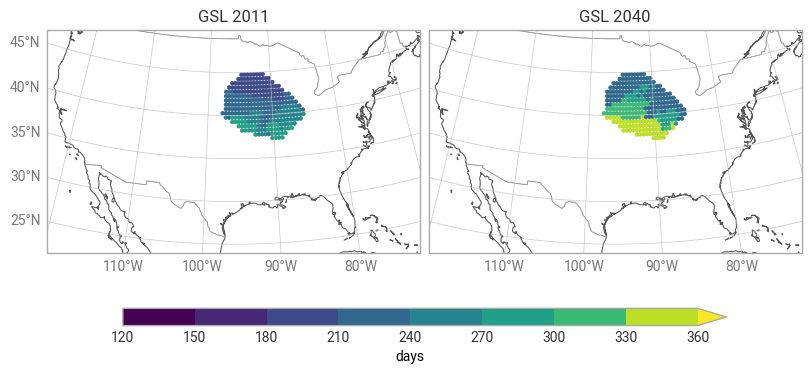

In [12]:
figure = ekp.Figure(rows=1, columns=2, domain="Contiguous United States")
ax = figure.add_map()
ax.point_cloud(ds_poly['GSL'].isel(datetimes=0),
    x=ds_poly['longitude'],
    y=ds_poly['latitude'],
    units='days',
    s=7,
    style=ekp.Style(levels=range(120,361,30),colors='viridis', extend="max"))
ax.title('{variable_name} 2011')

ax = figure.add_map()
ax.point_cloud(ds_poly['GSL'].isel(datetimes=-1),
    x=ds_poly['longitude'],
    y=ds_poly['latitude'],
    units='days',
    s=7,
    style=ekp.Style(levels=range(120,361,30),colors='viridis', extend="max"))
ax.title('{variable_name} 2040')

figure.coastlines()
figure.borders()
figure.gridlines()
figure.legend(label='days')
figure.show()


---

## Next steps

Now that you can retrieve the data, here are some things to try next:

- **Swap the variable** – replace `"growing_season_length"` with any of the 26
  available indicators (e.g. `"frost_days"`, `"summer_days"`, `"warm_spell_duration_index"`)
- **Compare scenarios** – run the same request twice with `"experiment": "rcp4_5"`
  and `"experiment": "rcp8_5"` and plot them side by side
- **Change the period** 
- **Use a real boundary** – load a country or region shapefile and convert it to a
  polygon for the API

Please see the constraints file, which contains the valid values for the `sis-agroclimatic-indicators` dataset.
